In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

## Agenda 1: Debugging

Fixed uncorrected pull being too large.

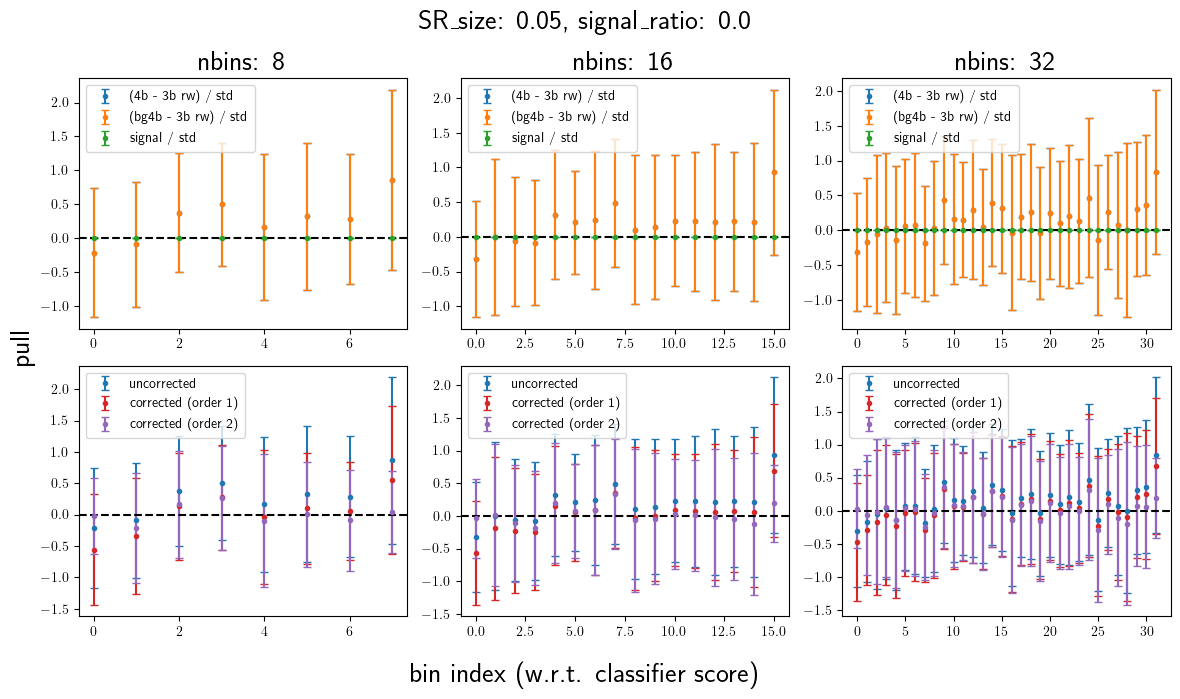

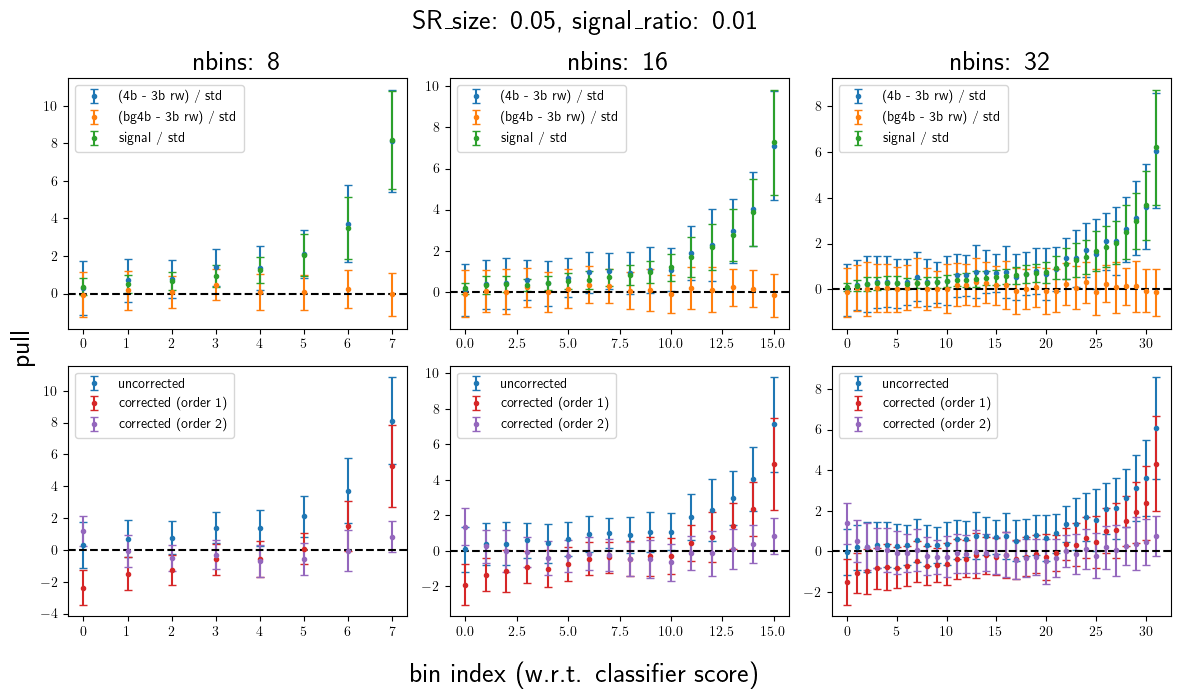

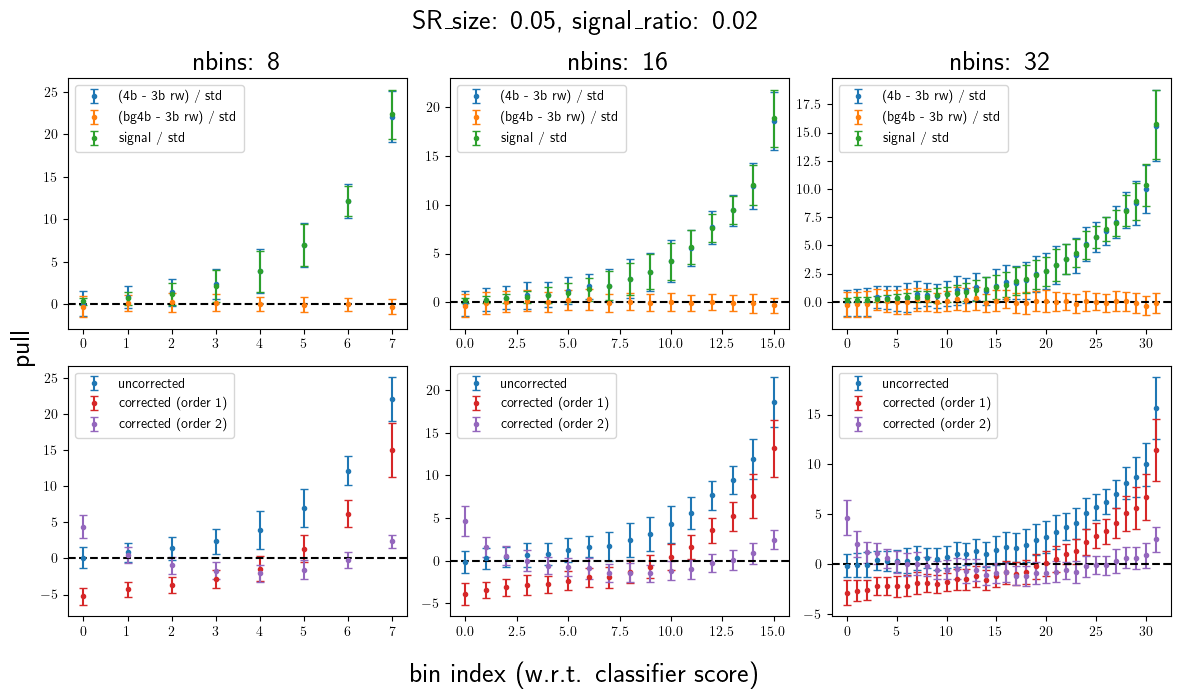

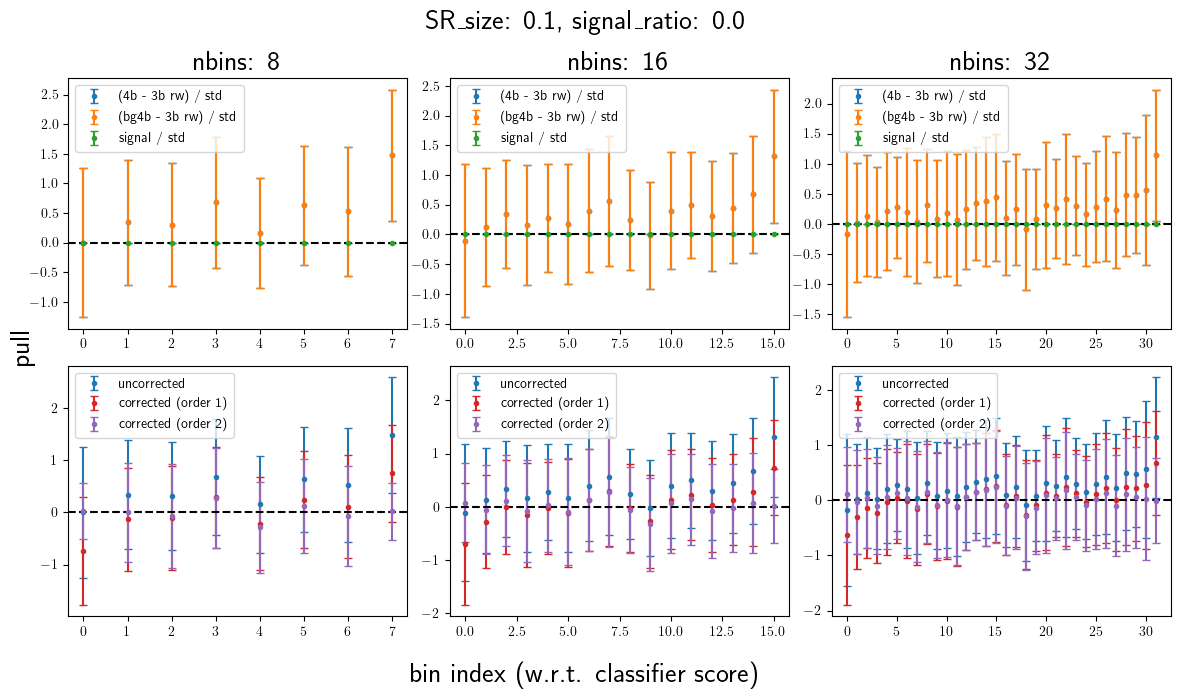

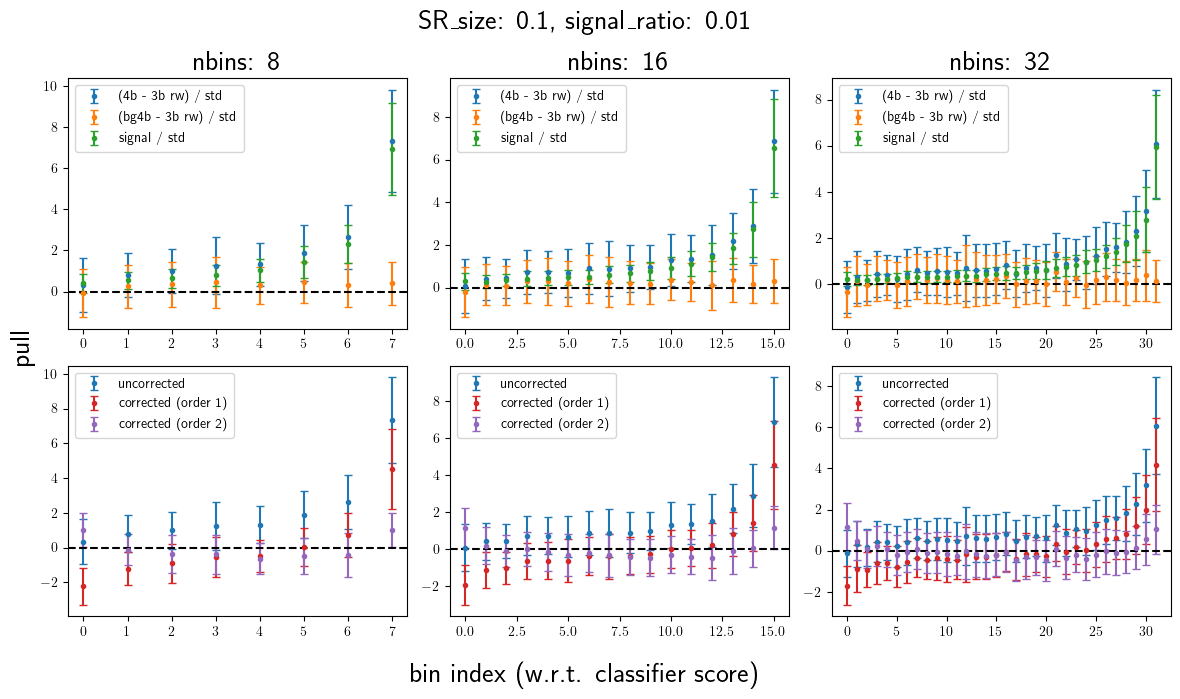

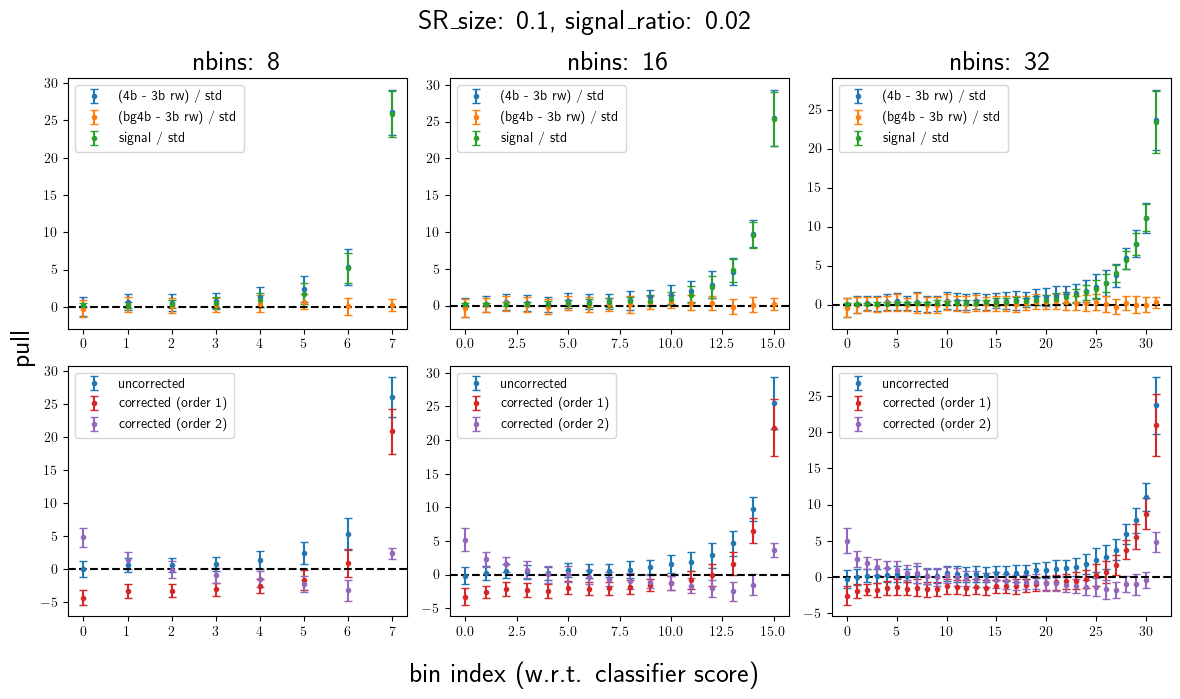

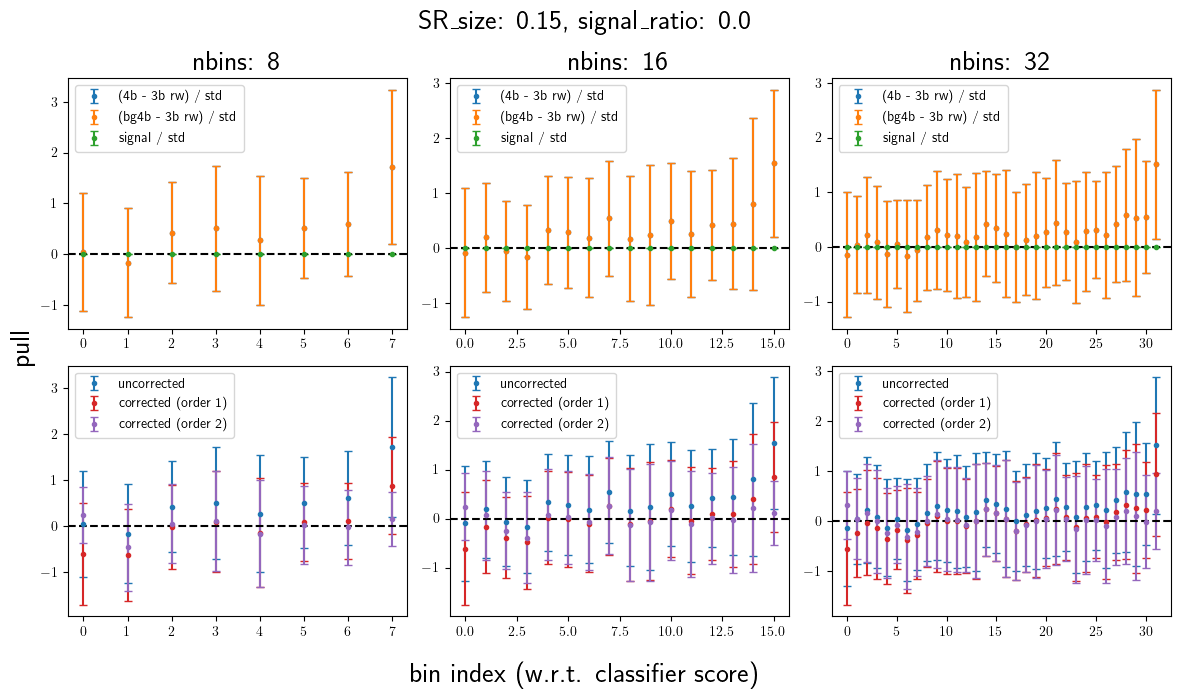

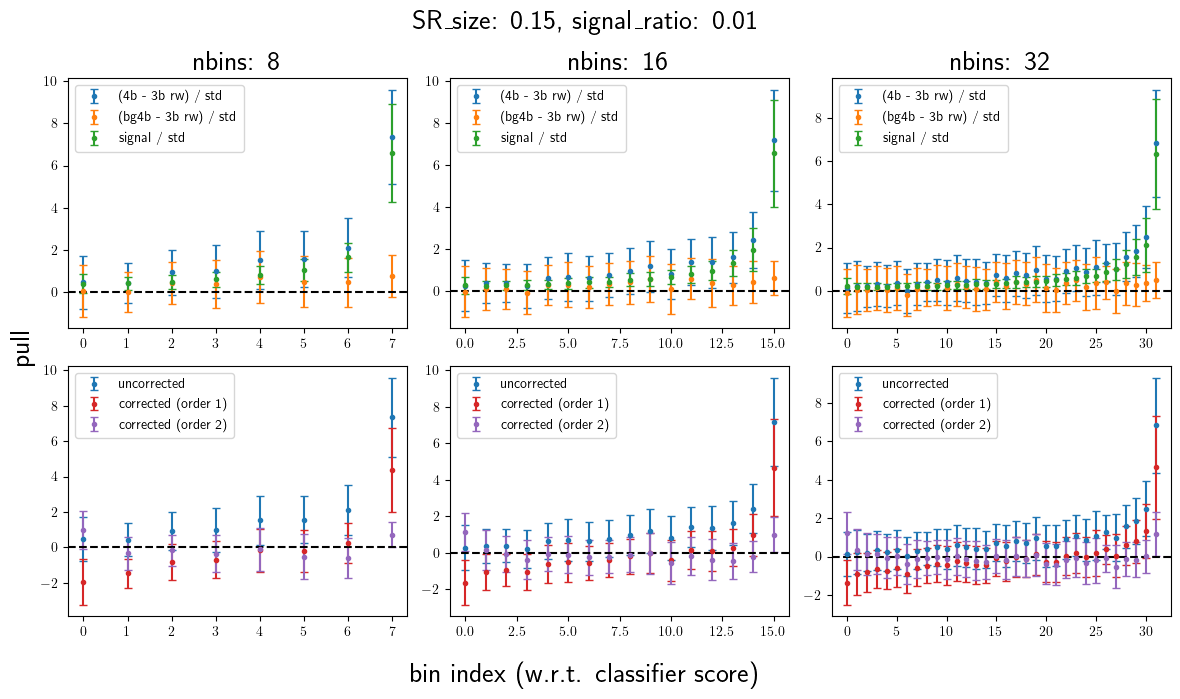

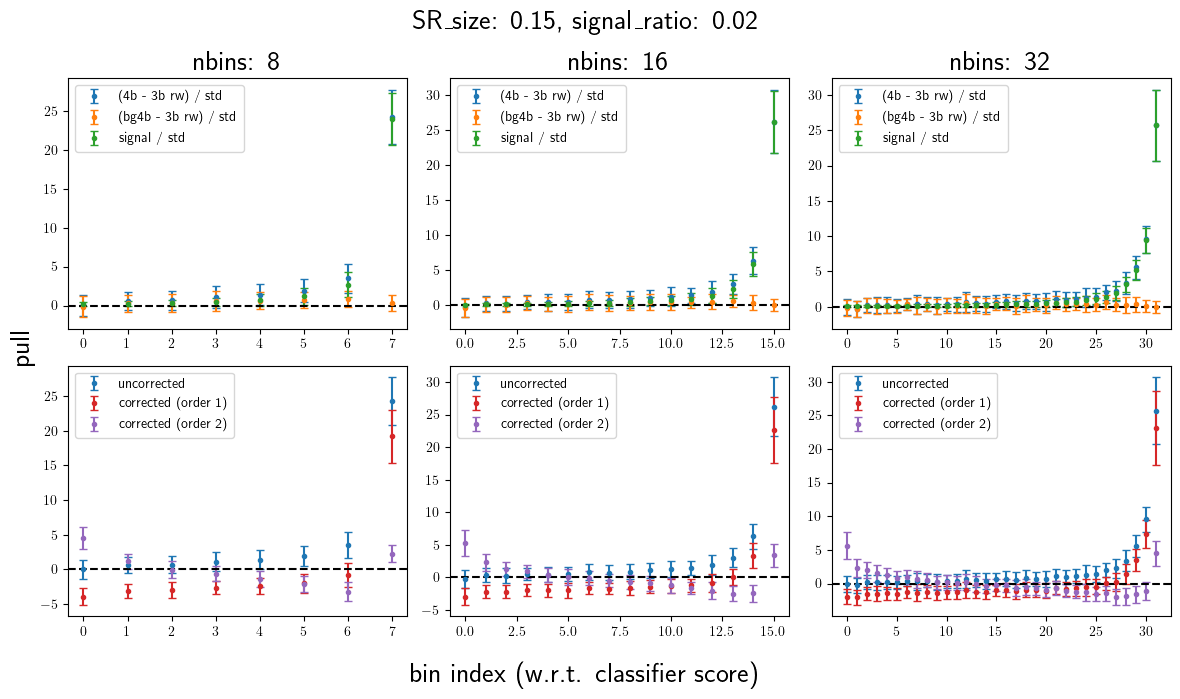

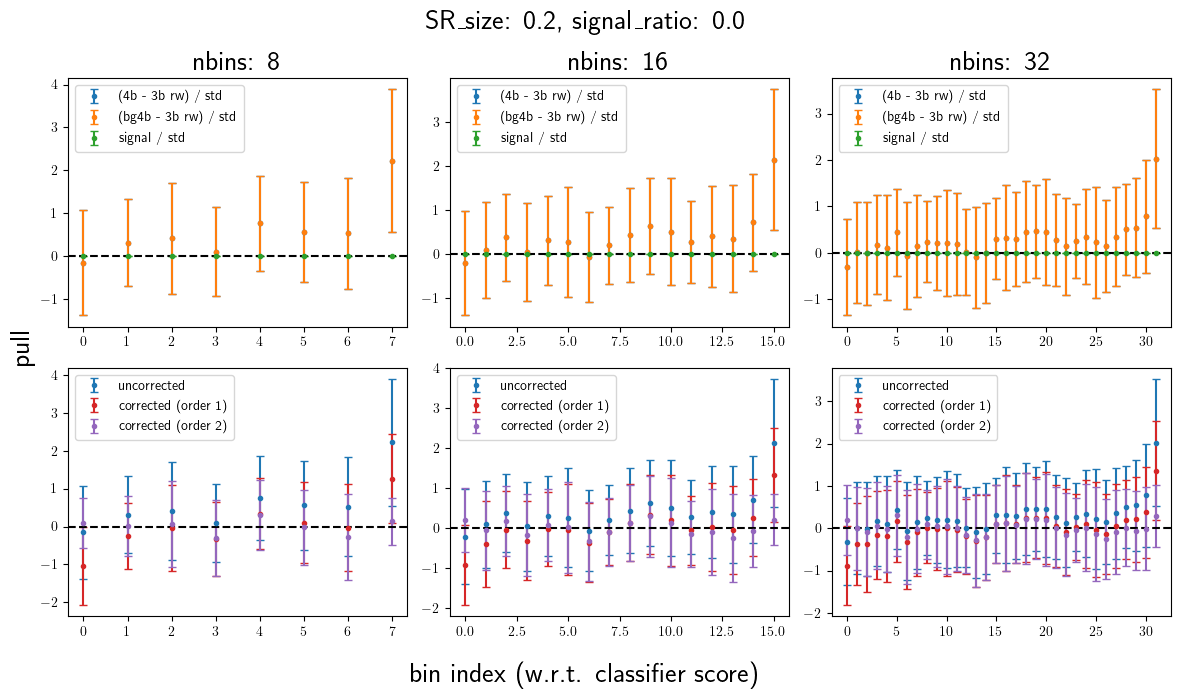

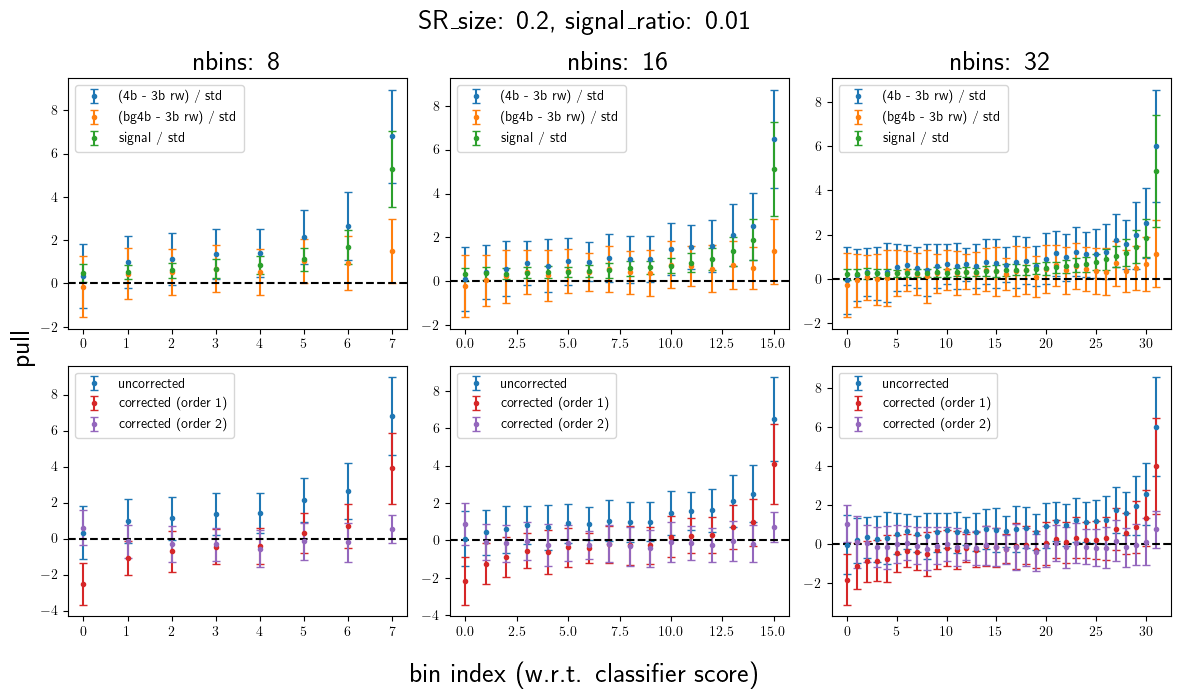

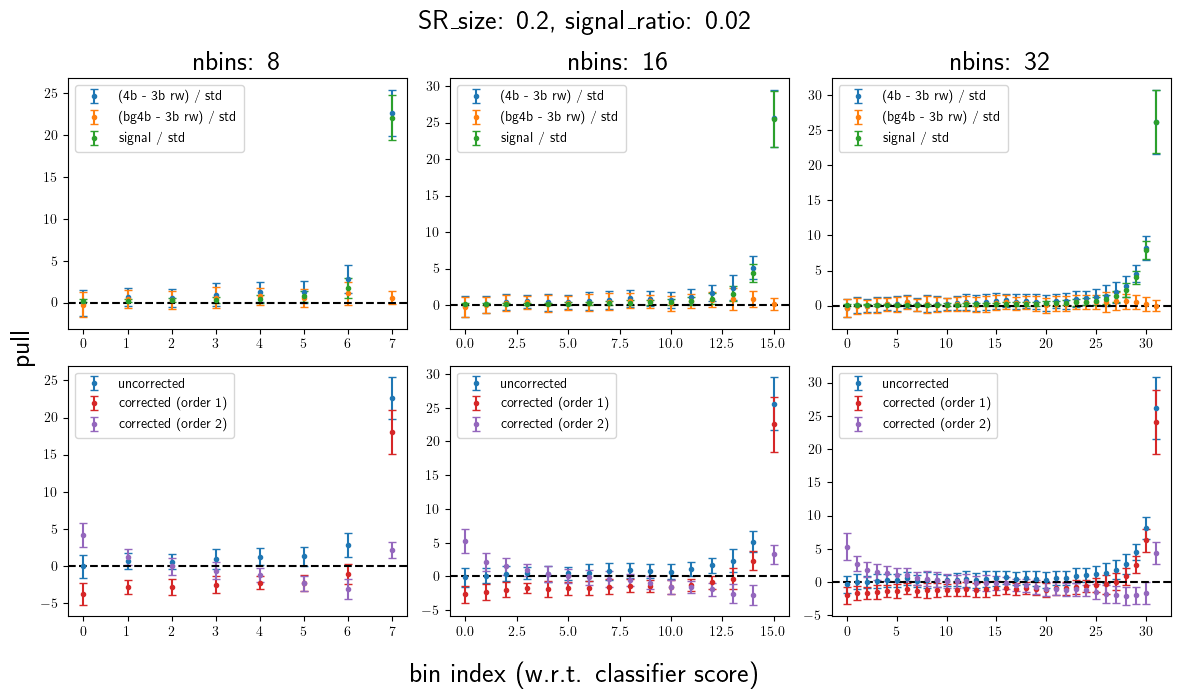

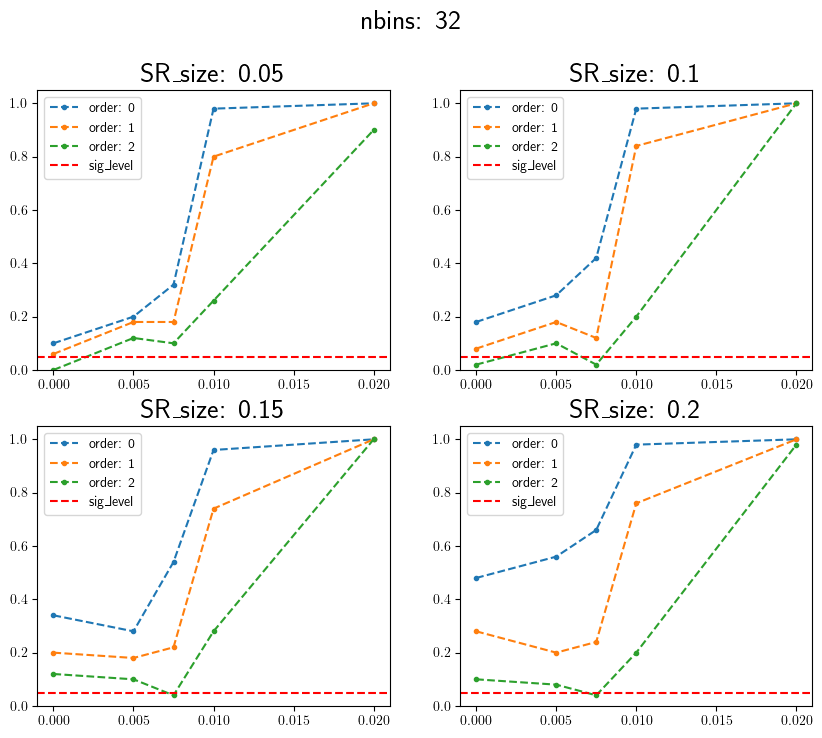

In [26]:
pull_dict = pickle.load(open("./data/tmp/pull_dict_mi_test.pkl", "rb"))
nbins_list = [8, 16, 32]
batch_size = 1024

for SR_size in [0.05, 0.1, 0.15, 0.2]:
    for signal_ratio in [0.0, 
                        #  0.005, 0.0075, 
                         0.01, 0.02]:
        fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 7))
        fig.suptitle(f"SR_size: {SR_size}, signal_ratio: {signal_ratio}")
        fig.supxlabel("bin index (w.r.t. classifier score)")
        fig.supylabel("pull")
        tmp_dict = [d for d in pull_dict if d["SR_size"] == SR_size 
                    and d["signal_ratio"] == signal_ratio 
                    and d["batch_size"] == batch_size]
        
        for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
            tmp_dict_nbins_0 = [d for d in tmp_dict if d["nbins"] == nbins and d["correction_order"] == 0]
            tmp_dict_nbins_1 = [d for d in tmp_dict if d["nbins"] == nbins and d["correction_order"] == 1]
            tmp_dict_nbins_2 = [d for d in tmp_dict if d["nbins"] == nbins and d["correction_order"] == 2]
            pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dict_nbins_0], axis=0)
            pull_signal_std = np.std([d["pull_signal"] for d in tmp_dict_nbins_0], axis=0)
            pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dict_nbins_0], axis=0)
            pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dict_nbins_0], axis=0)
            
            pull_mean = np.mean([d["pull_no_shape"] for d in tmp_dict_nbins_0], axis=0)
            pull_std = np.std([d["pull_no_shape"] for d in tmp_dict_nbins_0], axis=0)
            
            pull_mean_corrected_1 = np.mean([d["pull_no_shape"] for d in tmp_dict_nbins_1], axis=0)
            pull_std_corrected_1 = np.std([d["pull_no_shape"] for d in tmp_dict_nbins_1], axis=0)
            
            pull_mean_corrected_2 = np.mean([d["pull_no_shape"] for d in tmp_dict_nbins_2], axis=0)
            pull_std_corrected_2 = np.std([d["pull_no_shape"] for d in tmp_dict_nbins_2], axis=0)
            
            pull_shape_corrected = np.mean([d["pull_shape"] for d in tmp_dict_nbins_0], axis=0)
            pull_shape_corrected_std = np.std([d["pull_shape"] for d in tmp_dict_nbins_0], axis=0)
            
            current_ax_0 = ax[0, ax_idx]
            current_ax_0.set_title(f"nbins: {nbins}")
            bins = np.arange(nbins)
            current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
            current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[1])
            current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[2])
            current_ax_0.axhline(0, color="black", linestyle="--")
            current_ax_0.legend()
            
            current_ax_1 = ax[1, ax_idx]
            current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[0])
            current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[3])
            current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[4])
            current_ax_1.axhline(0, color="black", linestyle="--")
            current_ax_1.legend()
            
        plt.tight_layout()
        plt.show()
        
    colors = plt.get_cmap("tab10").colors



pull_df = pd.read_csv(f"./data/tmp/pull_df_mi_test.csv").drop(columns=["mi_test_hash"])
sig_level = 0.05

pull_df["p_value"] = chi2.sf(pull_df["nbins"] * (pull_df["mean_pull_sq_no_shape"] ** 2), 
                            #  df=pull_df["nbins"] - correction_order
                             df=pull_df["n_bins_eff"] - correction_order
                             )
pull_df["rejected"] = pull_df["p_value"] < sig_level
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "batch_size", "correction_order"]).mean().reset_index()


nbins = 32
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle(f"nbins: {nbins}")
for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
    current_ax = ax[ax_idx // 2, ax_idx % 2]
    current_ax.set_title(f"SR_size: {SR_size}")
    for correction_order in [0, 1, 2]:
        pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                        & (pull_df_summary["nbins"] == nbins)
                                        & (pull_df_summary["batch_size"] == 1024)
                                        & (pull_df_summary["correction_order"] == correction_order)
                                        ]
        current_ax.plot(pull_df_nbins["signal_ratio"], 
                 pull_df_nbins["rejected"], 
                 label=f"order: {correction_order}", 
                 color=colors[correction_order],
                 linestyle="--",
                 marker="o")
    current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
    current_ax.set_ylim(0, 1.05)
    current_ax.legend()
plt.show()

## Agenda 2

Marginal effect of CR variance (i.e. variance of $N_{3b}^{CR}$ and $N_{4b}^{CR}$) to pulls.

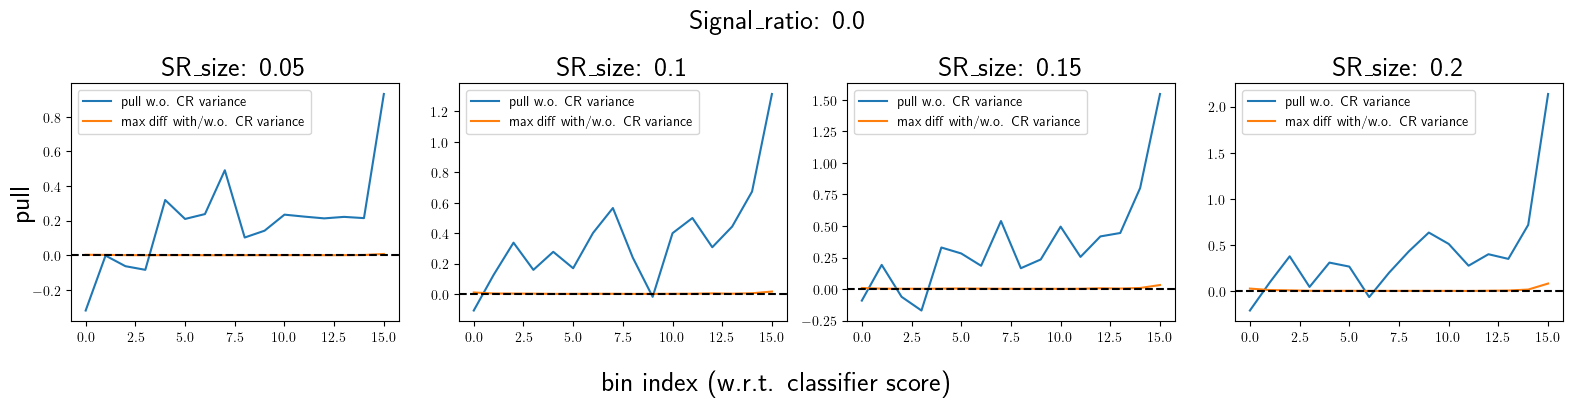

In [ ]:
pull_dict = pickle.load(open("./data/tmp/pull_dict_mi_test.pkl", "rb"))
batch_size = 1024
correction_order = 2
nbins = 16
signal_ratio = 0.0

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"Signal_ratio: {signal_ratio}")
fig.supxlabel("bin index (w.r.t. classifier score)")
fig.supylabel("pull")
for ax_cnt, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
    
    tmp_dict = [d for d in pull_dict if d["SR_size"] == SR_size 
                and d["signal_ratio"] == signal_ratio 
                and d["batch_size"] == batch_size]
    
    tmp_dict_nbins_0 = [d for d in tmp_dict if d["nbins"] == nbins and d["correction_order"] == 0]
    
    pull_mean = np.mean([d["pull_no_shape"] for d in tmp_dict_nbins_0], axis=0)
    pull_std = np.std([d["pull_no_shape"] for d in tmp_dict_nbins_0], axis=0)
    pull_diff = np.max([np.abs(d["pull_shape"] - d["pull_no_shape"]) for d in tmp_dict_nbins_0], axis=0)
    
    ax[ax_cnt].set_title(f"SR_size: {SR_size}")
    ax[ax_cnt].plot(pull_mean, label="pull w.o. CR variance")
    ax[ax_cnt].plot(pull_diff, label="max diff with/w.o. CR variance")
    ax[ax_cnt].axhline(0, color="black", linestyle="--")
    ax[ax_cnt].legend()

plt.tight_layout()
plt.show()

## Agenda 3

CR FvT underestimates 4b in the SR (in average.)  
Correction might be necessary.

In [28]:
ratio_4b_df = pd.read_csv(f"./data/tmp/ratio_4b_dict.csv")
ratio_4b_df["pull_est"] = (
    (ratio_4b_df["weight_4b_test"] - ratio_4b_df["weight_3b_test"]) / np.sqrt(ratio_4b_df["weight_4b_test"] + ratio_4b_df["weight_3b_test"]))

for SR_size in [0.05, 0.1, 0.15, 0.2]:
    print(f"SR_size: {SR_size}")
    display(ratio_4b_df.groupby(["SR_size"]).get_group((SR_size,))[["ratio_4b_test", "ratio_4b_train", "ratio_4b_CR", "pull_est"]].describe().loc[["mean", "std"]])


SR_size: 0.05


,ratio_4b_test,ratio_4b_train,ratio_4b_CR,pull_est
mean,0.503353,0.503366,0.500186,0.909922
std,0.004764,0.004569,0.001153,1.299977


SR_size: 0.1


,ratio_4b_test,ratio_4b_train,ratio_4b_CR,pull_est
mean,0.504481,0.504321,0.499684,1.723596
std,0.003924,0.003875,0.001318,1.507989


SR_size: 0.15


,ratio_4b_test,ratio_4b_train,ratio_4b_CR,pull_est
mean,0.503824,0.503804,0.499932,1.802145
std,0.003968,0.003846,0.000947,1.869645


SR_size: 0.2


,ratio_4b_test,ratio_4b_train,ratio_4b_CR,pull_est
mean,0.503768,0.503810,0.500020,2.049987
std,0.004038,0.003963,0.001081,2.201219


## Agenda 4: Updated Rejection Rate

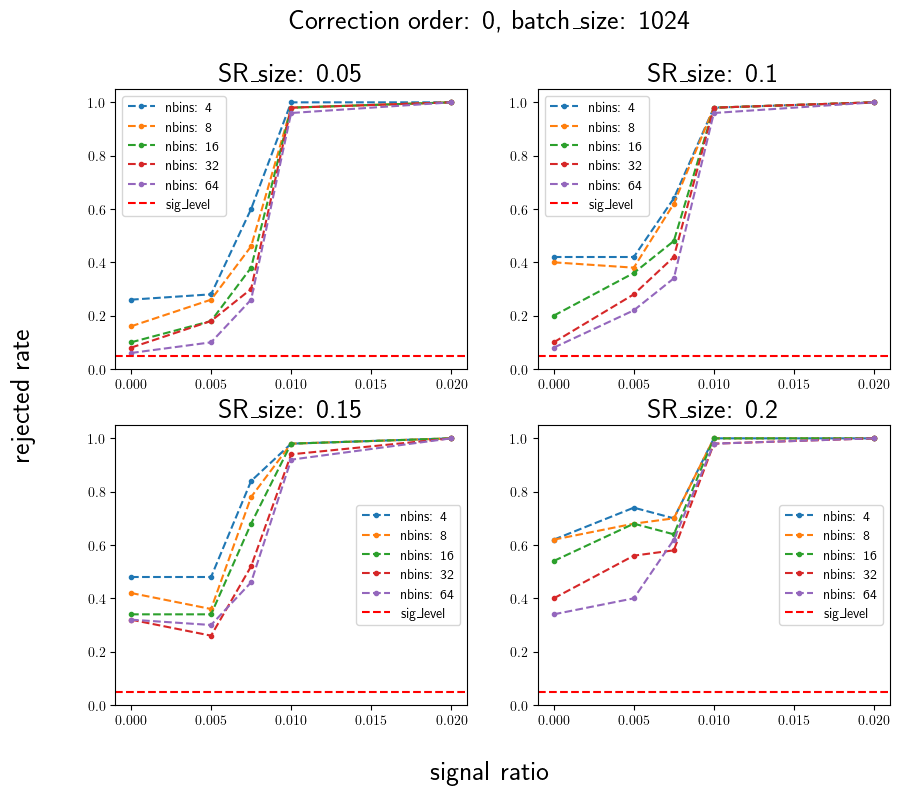

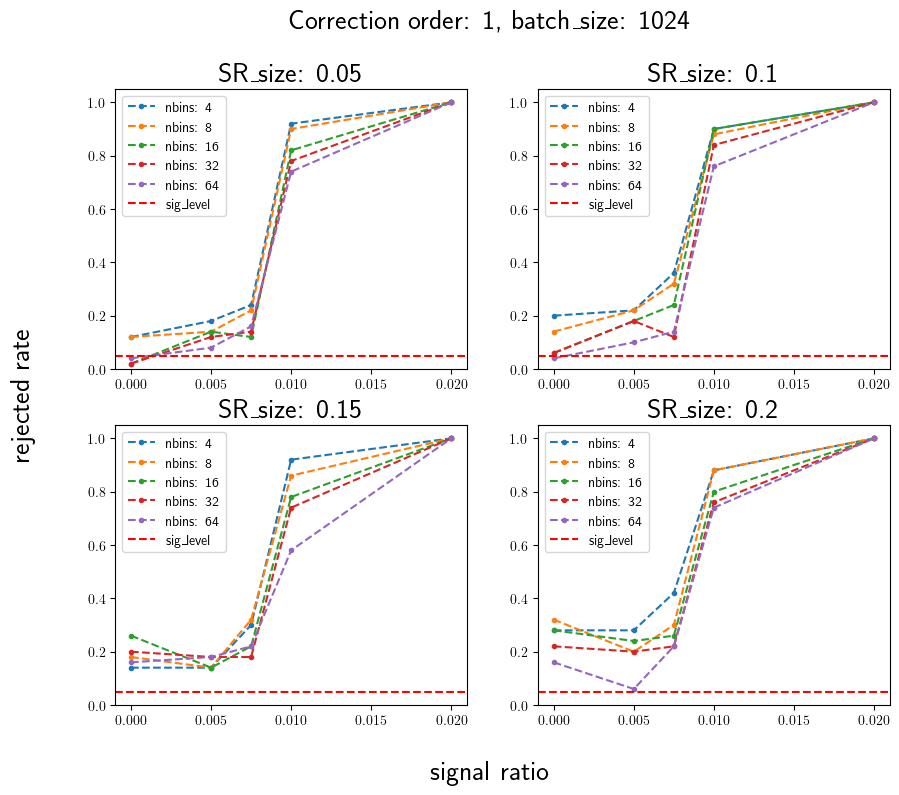

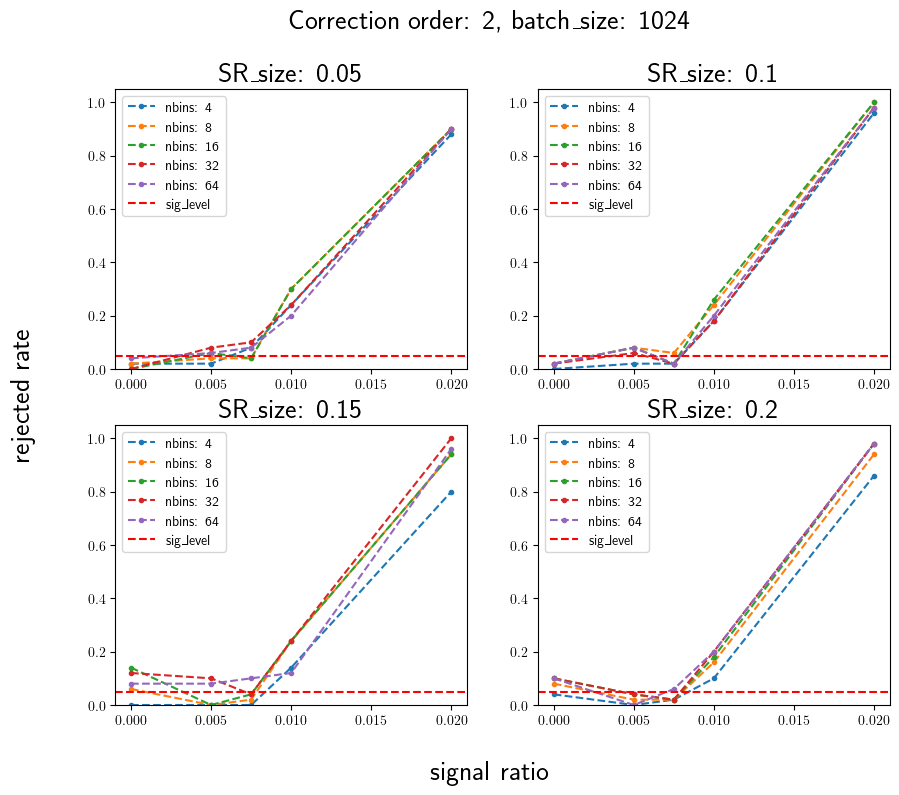

In [ ]:
from itertools import product
from scipy.stats import chi2


colors = plt.get_cmap("tab10").colors
correction_order = 1
batch_size = 1024
nbins_list = [4, 8, 16, 32, 64]

for correction_order in [0, 1, 2]:
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Correction order: {correction_order}, batch_size: {batch_size}")
    fig.supxlabel("signal ratio")
    fig.supylabel("rejected rate")
    for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        current_ax = ax[ax_idx // 2, ax_idx % 2]
        current_ax.set_title(f"SR_size: {SR_size}")
        for nbins in nbins_list:
            pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                            & (pull_df_summary["nbins"] == nbins)
                                            & (pull_df_summary["batch_size"] == batch_size)
                                            & (pull_df_summary["correction_order"] == correction_order)
                                            ]
            current_ax.plot(pull_df_nbins["signal_ratio"], 
                    pull_df_nbins["rejected"], 
                    label=f"nbins: {nbins}", 
                    color=colors[nbins_list.index(nbins)],
                    linestyle="--",
                    marker="o")
        current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
        current_ax.set_ylim(0, 1.05)
        current_ax.legend()
    plt.show()

Some histograms that might help.

signal_ratio 0.0 SR_CR_size 0.05 0.95


  0%|          | 0/3 [00:00<?, ?it/s]

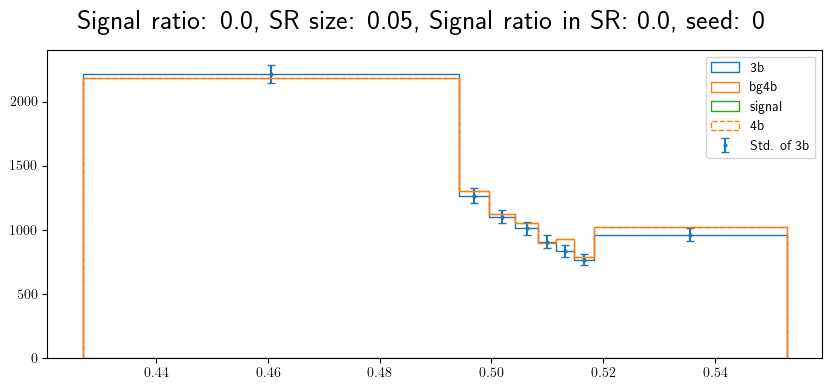

 33%|███▎      | 1/3 [00:01<00:03,  1.63s/it]

MS pull:  0.9059042
Rej C:  1.3922694178869195
Rejected:  False


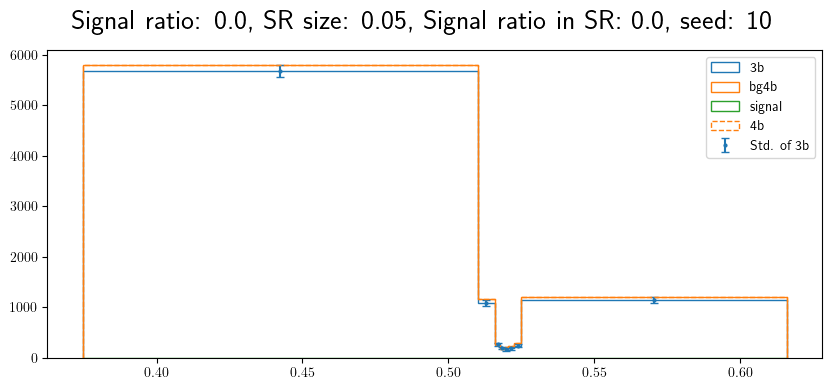

 67%|██████▋   | 2/3 [00:03<00:01,  1.64s/it]

MS pull:  1.3336931
Rej C:  1.3922694178869195
Rejected:  False


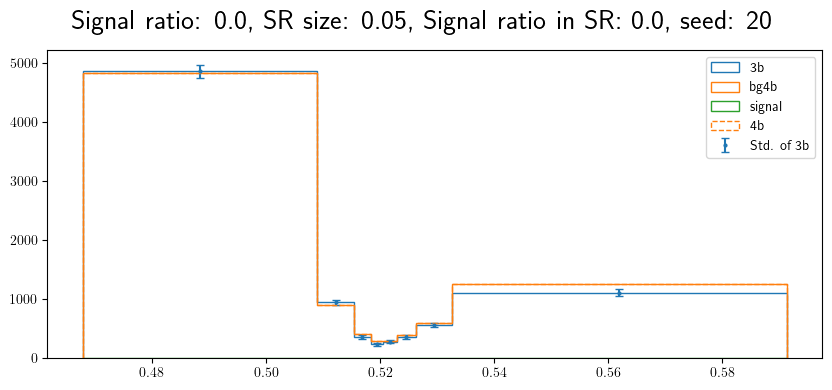

100%|██████████| 3/3 [00:04<00:00,  1.65s/it]


MS pull:  1.4986448
Rej C:  1.3922694178869195
Rejected:  True
signal_ratio 0.01 SR_CR_size 0.05 0.95


  0%|          | 0/3 [00:00<?, ?it/s]

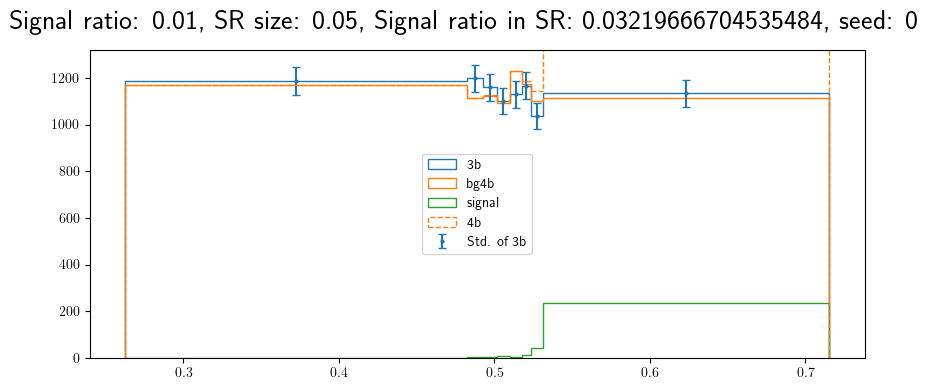

 33%|███▎      | 1/3 [00:01<00:03,  1.94s/it]

MS pull:  1.6942565
Rej C:  1.3922694178869195
Rejected:  True


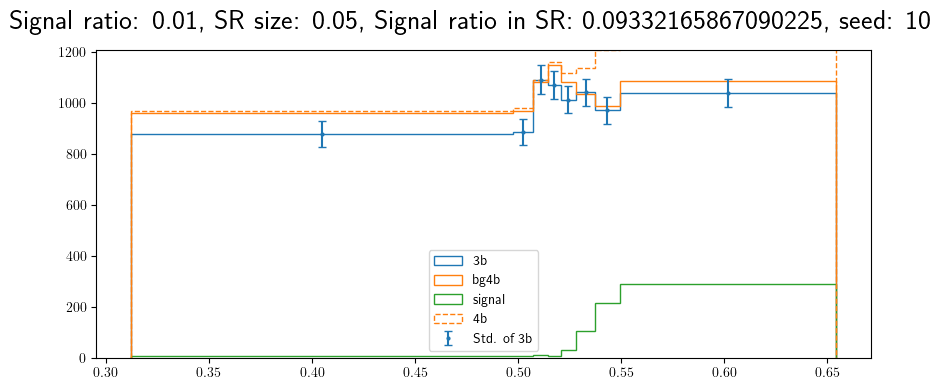

 67%|██████▋   | 2/3 [00:03<00:01,  1.82s/it]

MS pull:  3.7448127
Rej C:  1.3922694178869195
Rejected:  True


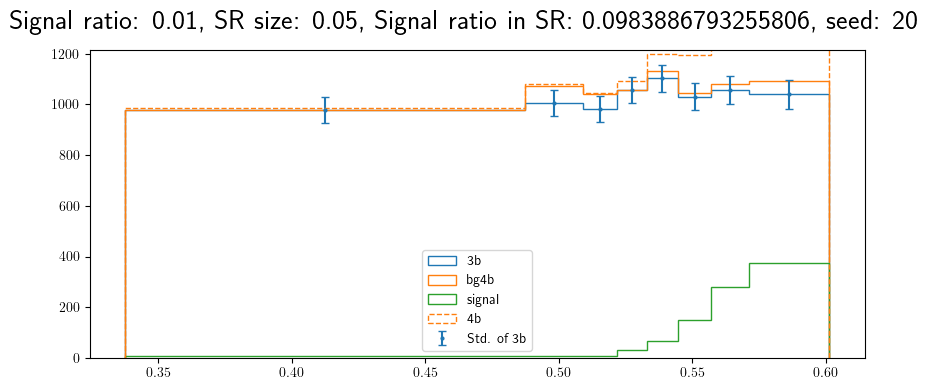

100%|██████████| 3/3 [00:05<00:00,  1.79s/it]


MS pull:  3.5653205
Rej C:  1.3922694178869195
Rejected:  True
signal_ratio 0.0 SR_CR_size 0.1 0.9


  0%|          | 0/3 [00:00<?, ?it/s]

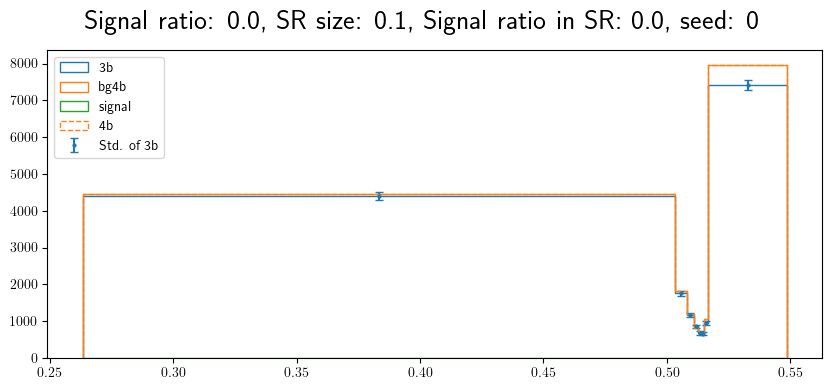

 33%|███▎      | 1/3 [00:01<00:03,  1.87s/it]

MS pull:  1.7557306
Rej C:  1.3922694178869195
Rejected:  True


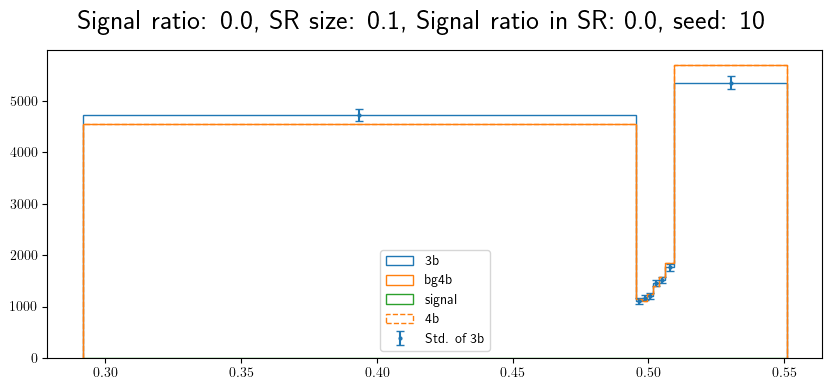

 67%|██████▋   | 2/3 [00:03<00:01,  1.74s/it]

MS pull:  1.3988693
Rej C:  1.3922694178869195
Rejected:  True


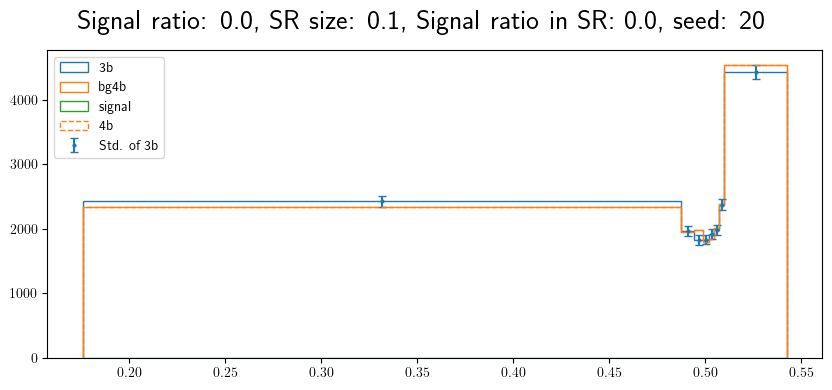

100%|██████████| 3/3 [00:05<00:00,  1.71s/it]


MS pull:  1.0145135
Rej C:  1.3922694178869195
Rejected:  False
signal_ratio 0.01 SR_CR_size 0.1 0.9


  0%|          | 0/3 [00:00<?, ?it/s]

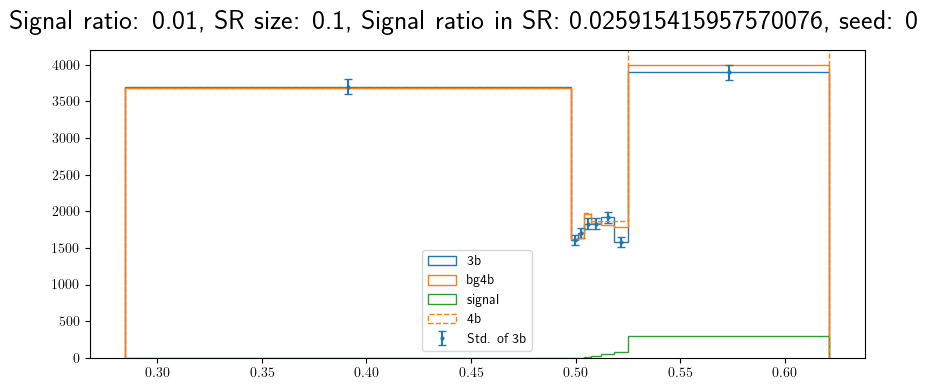

 33%|███▎      | 1/3 [00:01<00:03,  1.95s/it]

MS pull:  2.1727862
Rej C:  1.3922694178869195
Rejected:  True


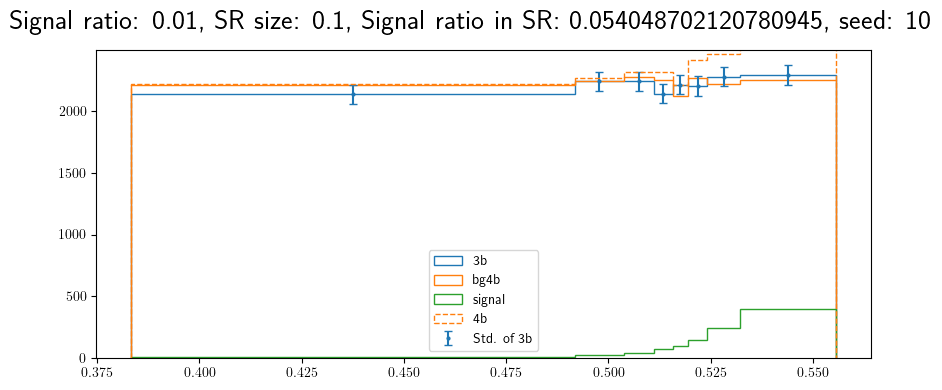

 67%|██████▋   | 2/3 [00:03<00:01,  1.81s/it]

MS pull:  2.2030632
Rej C:  1.3922694178869195
Rejected:  True


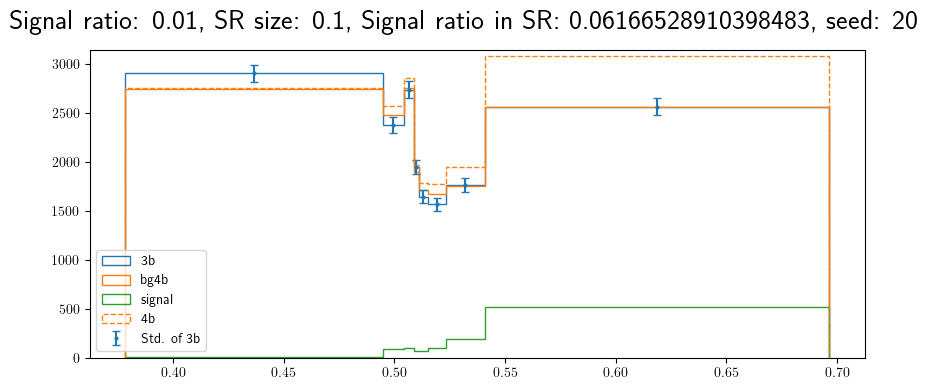

100%|██████████| 3/3 [00:05<00:00,  1.79s/it]


MS pull:  2.9206326
Rej C:  1.3922694178869195
Rejected:  True
signal_ratio 0.0 SR_CR_size 0.2 0.8


  0%|          | 0/3 [00:00<?, ?it/s]

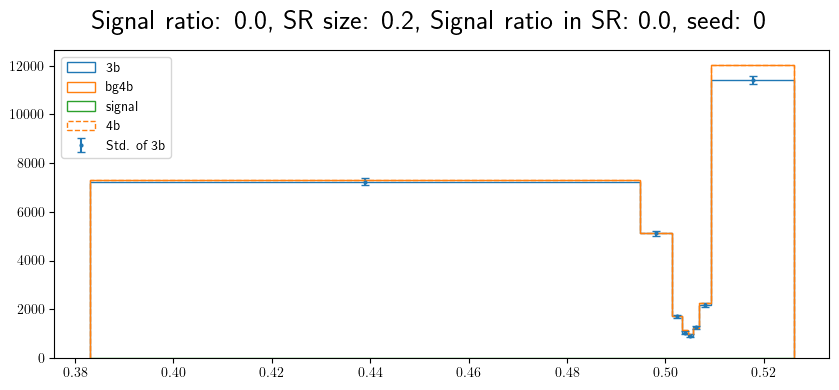

 33%|███▎      | 1/3 [00:01<00:03,  1.64s/it]

MS pull:  1.588069
Rej C:  1.3922694178869195
Rejected:  True


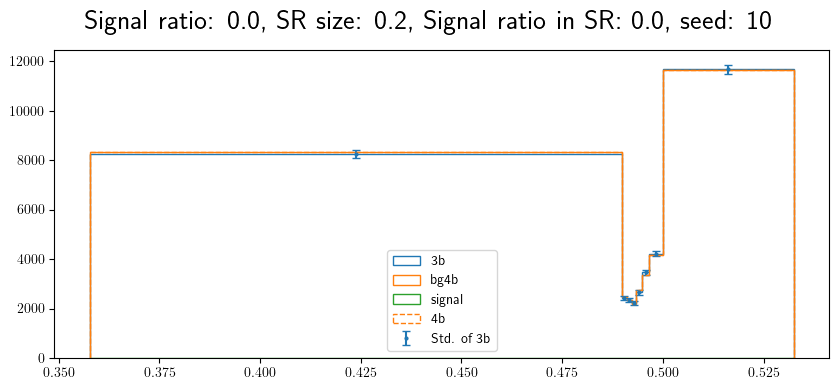

 67%|██████▋   | 2/3 [00:03<00:01,  1.81s/it]

MS pull:  0.7148597
Rej C:  1.3922694178869195
Rejected:  False


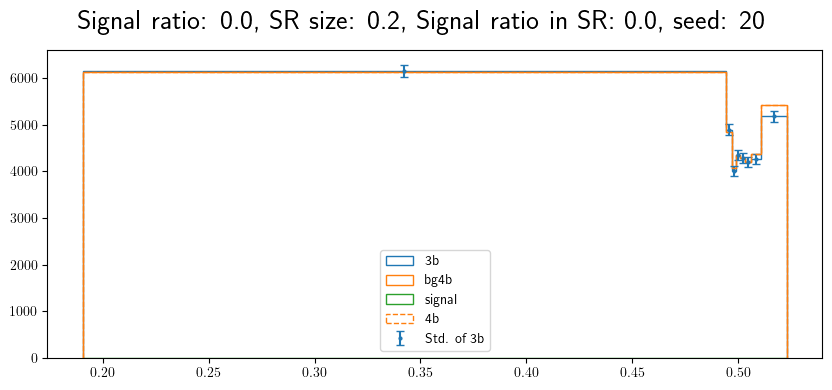

100%|██████████| 3/3 [00:05<00:00,  1.83s/it]


MS pull:  0.8456213
Rej C:  1.3922694178869195
Rejected:  False
signal_ratio 0.01 SR_CR_size 0.2 0.8


  0%|          | 0/3 [00:00<?, ?it/s]

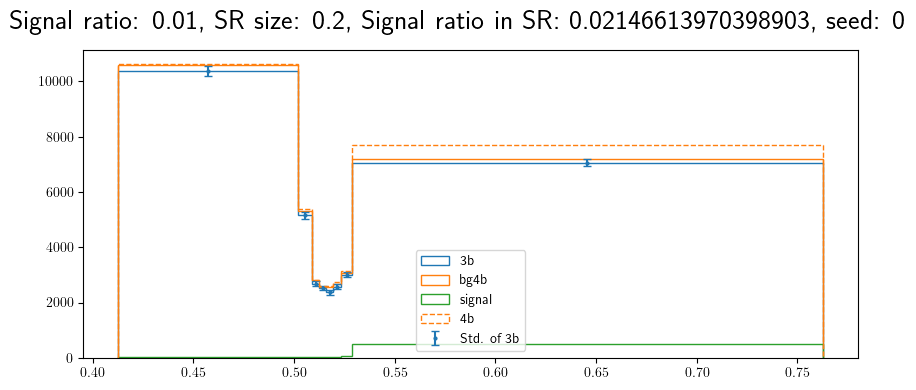

 33%|███▎      | 1/3 [00:01<00:03,  1.80s/it]

MS pull:  2.3348312
Rej C:  1.3922694178869195
Rejected:  True


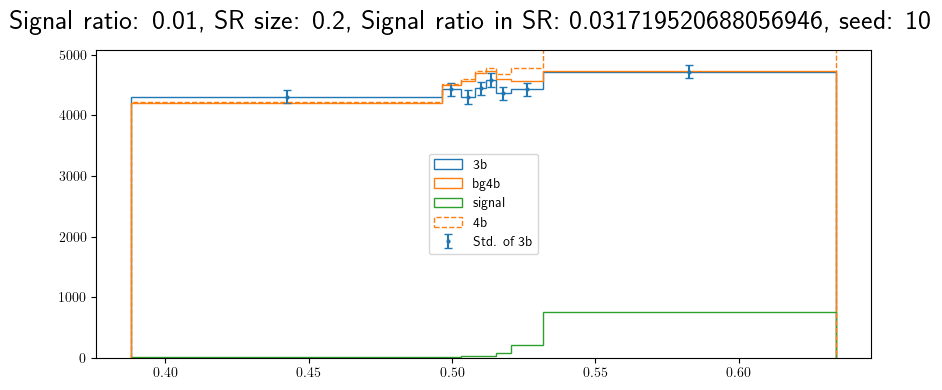

 67%|██████▋   | 2/3 [00:03<00:01,  1.92s/it]

MS pull:  3.2277024
Rej C:  1.3922694178869195
Rejected:  True


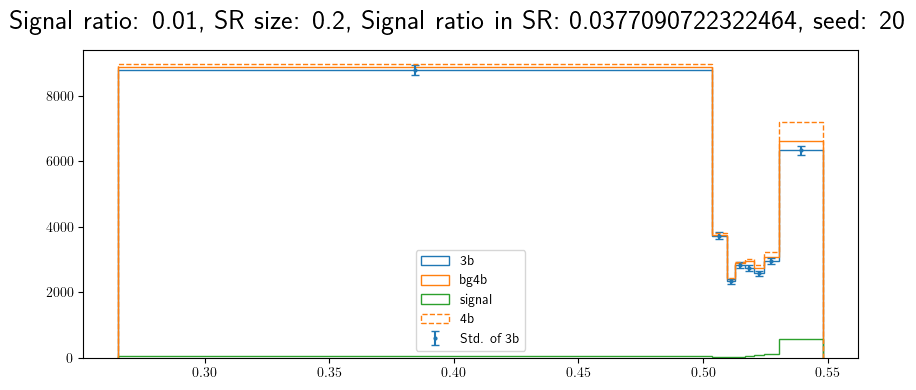

100%|██████████| 3/3 [00:05<00:00,  1.86s/it]

MS pull:  3.6381779
Rej C:  1.3922694178869195
Rejected:  True


In [33]:
from plots import calibration_plot
from signal_region import get_SR_CR_cut, compute_sr_stats
from events_data import get_is_signal
from utils import select_random_true_elements, get_quantiles_with_weights
from mi_test import mi_test, calibrate_fvt_scores_cv
from correct_systematic_error import get_histograms
from scipy.stats import chi2
from tqdm import tqdm

n_3b = 100_0000
ratio_4b = 0.5
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_ensemble_max_smeared"
N_REPS = 1000
tst_seed = 42

SR_CR_sizes = [
    (0.05, 0.95), 
    (0.1, 0.9),
    # (0.15, 0.85),
    (0.2, 0.8),
               ]
renyi_alpha = 2

n_calib_bins = 8
for SR_size, CR_size in SR_CR_sizes:
    for signal_ratio in [0.0, 0.01]:
            print("signal_ratio", signal_ratio, "SR_CR_size", SR_size, CR_size)
            hparams_filter = {
                "experiment_name": experiment_name,
                "aux_info_step": 3,
                "dataset": lambda x: (
                    x["n_3b"] == n_3b
                    and x["ratio_4b"] == ratio_4b
                    and x["signal_filename"] == signal_filename
                    and x["signal_ratio"] == signal_ratio
                    and x["seed"] in [0, 10, 20]
                ),
                "signal_region": lambda x: (
                    x["4b_in_SR"] == SR_size and x["4b_in_CR"] == CR_size
                ),
            }
            CR_fvt_hashes = TrainingInfo.find(hparams_filter)
            # sort by seed
            CR_fvt_hashes = sorted(CR_fvt_hashes, key=lambda x: TrainingInfo.load(x).hparams["dataset"]["seed"])
            
            for CR_fvt_hash in tqdm(CR_fvt_hashes):
                hparams_filter = {"CR_fvt_hash": CR_fvt_hash, 
                                  "dataloader": lambda x: x["batch_size"] == 1024}
                mi_test_hash = TrainingInfo.find(hparams_filter)
                if not len(mi_test_hash) == 1:
                    for h in mi_test_hash:
                        print(TrainingInfo.load(h).hparams)
                    raise ValueError("len(mi_test_hash) != 1")
                mi_test_hash = mi_test_hash[0]
                mi_test_tinfo = TrainingInfo.load(mi_test_hash)
                CR_fvt_tinfo = TrainingInfo.load(CR_fvt_hash)
                SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
                ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
                stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
                signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]

                ms_idx = TrainingInfo.load(SR_stats_hashes[0]).ms_idx
                msamples = MotherSamples.load(CR_fvt_tinfo.ms_hash)
                train_scdinfo = msamples.scdinfo[ms_idx]
                tst_scdinfo = msamples.scdinfo[~ms_idx]

                df_train = train_scdinfo.fetch_data(loaded_df)
                df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
                events_train = EventsData.from_dataframe(df_train, features)

                df_tst = tst_scdinfo.fetch_data(loaded_df)
                df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
                events_tst = EventsData.from_dataframe(df_tst, features)

                SR_stats_train, SR_stats_tst = compute_sr_stats(
                    SR_stats_hashes,
                    signal_filename,
                    ensemble_mode,
                    stats_type,
                    loaded_df,
                )
                
                SR_cut, _ = get_SR_CR_cut(
                    SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
                )
                SR_idx = SR_stats_tst >= SR_cut
                
                SR_3b_idx = events_tst.is_3b & SR_idx
                SR_4b_idx = events_tst.is_4b & SR_idx
                
                mi_test_test_ratio = mi_test_tinfo.hparams["mi_test_dataset"]["test_ratio"]
                mi_test_data_seed = mi_test_tinfo.hparams["mi_test_dataset"]["data_seed"]

                # select test_ratio of the events in the SR for 3b and 4b
                SR_3b_test_idx = select_random_true_elements(
                    SR_3b_idx,
                    mi_test_test_ratio,
                    mi_test_data_seed,
                )
                SR_4b_test_idx = select_random_true_elements(
                    SR_4b_idx,
                    mi_test_test_ratio,
                    mi_test_data_seed,
                )
                
            

                SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
                events_tst_SR_test = events_tst[SR_test_idx]
                events_tst_SR_train = events_tst[SR_idx & ~SR_test_idx]
                fvt_scores_tst_SR_test = mi_test_tinfo.aux_info["fvt_scores_tst_SR_test"]
                fvt_scores_tst_SR_train = mi_test_tinfo.aux_info["fvt_scores_tst_SR_train"]
                reweights_tst_SR_test = mi_test_tinfo.aux_info["reweights_tst_SR_test"]
                reweights_tst_SR_train = mi_test_tinfo.aux_info["reweights_tst_SR_train"]
                
                # calibrate the fvt scores
                
                
                SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
                SR_test_idx_in_SR_tst = SR_test_idx[SR_idx]
                SR_train_idx_in_SR_tst = ~SR_test_idx_in_SR_tst
                
                tst_idx = np.zeros_like(SR_3b_test_idx, dtype=int)
                tst_idx[SR_3b_test_idx] = 1
                tst_idx[SR_4b_test_idx] = 2
                tst_idx = tst_idx[tst_idx != 0]
                SR_3b_test_idx = tst_idx == 1
                SR_4b_test_idx = tst_idx == 2
                
                events_tst_SR_test_clone = events_tst_SR_test.clone()
                events_tst_SR_train_clone = events_tst_SR_train.clone()
                reweights_tst_SR_train = mi_test_tinfo.aux_info["reweights_tst_SR_train"]
                reweights_tst_SR_test = mi_test_tinfo.aux_info["reweights_tst_SR_test"]
                events_tst_SR_test_clone.reweight(reweights_tst_SR_test * events_tst_SR_test.weights)
                events_tst_SR_train_clone.reweight(reweights_tst_SR_train * events_tst_SR_train.weights)
                
                weights_test = events_tst_SR_test.weights * reweights_tst_SR_test
                weights_train = events_tst_SR_train.weights * reweights_tst_SR_train
                
                pi = np.sum(weights_train[events_tst_SR_train.is_4b]) / np.sum(weights_train)
                
                calib_bins = get_quantiles_with_weights(fvt_scores_tst_SR_train[events_tst_SR_train.is_3b], 
                                                        events_tst_SR_train_clone.weights[events_tst_SR_train.is_3b], 
                                                        np.linspace(0, 1, n_calib_bins + 1))
                fig, ax = plt.subplots(1, 1, figsize=(10, 4))
                fig.suptitle(f"Signal ratio: {signal_ratio}, SR size: {SR_size}, Signal ratio in SR: {events_tst_SR_test.total_weight_signal / events_tst_SR_test.total_weight_4b}, seed: {CR_fvt_tinfo.hparams['dataset']['seed']}")
                hist_events_by_labels(events_tst_SR_test_clone, fvt_scores_tst_SR_test, bins=calib_bins, ax=ax, errorbar=True)
                ax.hist(fvt_scores_tst_SR_test[events_tst_SR_test.is_4b], 
                        weights=events_tst_SR_test_clone.weights[events_tst_SR_test.is_4b], 
                        bins=calib_bins, label="4b", histtype="step", linestyle="--", color=plt.get_cmap("tab10").colors[1])
                ax.legend()
                plt.show()
                
                calib_bins[0] = np.min([calib_bins[0], np.min(fvt_scores_tst_SR_test)])
                calib_bins[-1] = np.max([calib_bins[-1], np.max(fvt_scores_tst_SR_test)])
                
                hists = get_histograms(events_tst_SR_test_clone, 
                               fvt_scores_tst_SR_test, 
                               calib_bins, 
                               1)
                hist_3b = hists["3b"]
                hist_4b = hists["4b"]
                hist_3b_sq = hists["3b_sq"]
                hist_4b_sq = hists["4b_sq"]
                
                pull_no_shape = (hist_4b - hist_3b) / np.sqrt(hist_4b_sq + hist_3b_sq)
                ms_pull = np.sqrt(np.mean(pull_no_shape**2))
                print("MS pull: ", ms_pull)
                
                rej_c = chi2.ppf(0.95, df=n_calib_bins)
                print("Rej C: ", np.sqrt(rej_c / n_calib_bins))
                print("Rejected: ", np.sum(pull_no_shape**2) > rej_c)